In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from matplotlib import pyplot as plt

%matplotlib widget

In [2]:
exam_result_path = Path("/Users/abelluc/FAUbox/DigiKolleg/ADS/Grading/2026-02_Retake/1770297120__0__tst__results_137268.csv")

In [3]:
exam_results = pd.read_csv(exam_result_path, sep=";")
exam_results

,Name,Login,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,Time of Work,Average Time of Work,...,STAT_p-value,STAT_parametric_vs_non-parametric_b,STAT_power,STAT_unifactorial_anova,VIS_boxplots_b,VIS_histograms_2_b,VIS_scatter_plots_2,VIS_scatter_plots_b,VIS_STAT_outliers,VIS_STAT_outliers2_b
0,"Ananda Kumar, Tejashree",qy72fexa,87.0,100,passed,49,49,1.000000,00:31:23,00:00:38,...,2,2,2,1,2.0,2,2,1.0,2,2
1,"Ande, Sandeep",bu41lobi,85.0,100,passed,49,49,1.000000,00:48:09,00:00:58,...,2,2,2,2,2.0,2,2,1.0,2,2
2,"Chakraborty, Debanjan",exam84701,81.0,100,passed,46,49,0.938776,00:58:13,00:01:15,...,2,2,2,2,2.0,2,0,2.0,2,2
3,"Chattopadhyay, Souhardya",ow85ymut,79.0,100,passed,49,49,1.000000,00:54:29,00:01:06,...,2,2,1,2,2.0,2,2,1.0,2,2
4,"Chavan, Vaibhav Shashikant",xy37jeqy,62.5,100,passed,38,49,0.775510,00:46:45,00:01:13,...,2,2,2,2,0.0,2,2,0.0,2,2
5,"Chen, Liwen",iz67evez,80.5,100,passed,49,49,1.000000,00:56:22,00:01:09,...,2,2,2,2,1.5,2,2,2.0,2,2
6,"David Karthikeyan, Akilan",ug39owys,82.5,100,passed,48,49,0.979592,00:56:41,00:01:10,...,2,2,2,2,2.0,2,2,0.5,2,2
7,"Desai, Mit Ashokbhai",ot79cogo,11.5,100,failed,48,49,0.979592,00:45:25,00:00:56,...,0,0,0,0,1.5,1,0,0.0,0,0
8,"Dua, Kasvi",id64ojik,32.5,100,failed,34,49,0.693878,00:40:32,00:01:11,...,2,0,0,0,1.0,2,2,0.0,0,1
9,"Durai, Subash",po91pesy,74.0,100,passed,42,49,0.857143,00:58:43,00:01:23,...,2,2,2,2,1.0,0,2,1.0,0,2


In [4]:
#handle special cases

exam_results.replace("exam84701", "vy06qypi", inplace=True)
exam_results.replace("exam73680", "ij74ysab", inplace=True) 

In [5]:
exam_results.set_index("Login", inplace=True)
exam_results.index.names = ["student_id"]
exam_results.head()

,Name,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,Time of Work,Average Time of Work,First Visit,...,STAT_p-value,STAT_parametric_vs_non-parametric_b,STAT_power,STAT_unifactorial_anova,VIS_boxplots_b,VIS_histograms_2_b,VIS_scatter_plots_2,VIS_scatter_plots_b,VIS_STAT_outliers,VIS_STAT_outliers2_b
student_id,,,,,,,,,,,,,,,,,,,,,
qy72fexa,"Ananda Kumar, Tejashree",87.0,100,passed,49,49,1.000000,00:31:23,00:00:38,"3. Feb 2026, 10:01",...,2,2,2,1,2.0,2,2,1.0,2,2
bu41lobi,"Ande, Sandeep",85.0,100,passed,49,49,1.000000,00:48:09,00:00:58,"3. Feb 2026, 10:01",...,2,2,2,2,2.0,2,2,1.0,2,2
vy06qypi,"Chakraborty, Debanjan",81.0,100,passed,46,49,0.938776,00:58:13,00:01:15,"3. Feb 2026, 10:12",...,2,2,2,2,2.0,2,0,2.0,2,2
ow85ymut,"Chattopadhyay, Souhardya",79.0,100,passed,49,49,1.000000,00:54:29,00:01:06,"3. Feb 2026, 10:00",...,2,2,1,2,2.0,2,2,1.0,2,2
xy37jeqy,"Chavan, Vaibhav Shashikant",62.5,100,passed,38,49,0.775510,00:46:45,00:01:13,"3. Feb 2026, 10:08",...,2,2,2,2,0.0,2,2,0.0,2,2


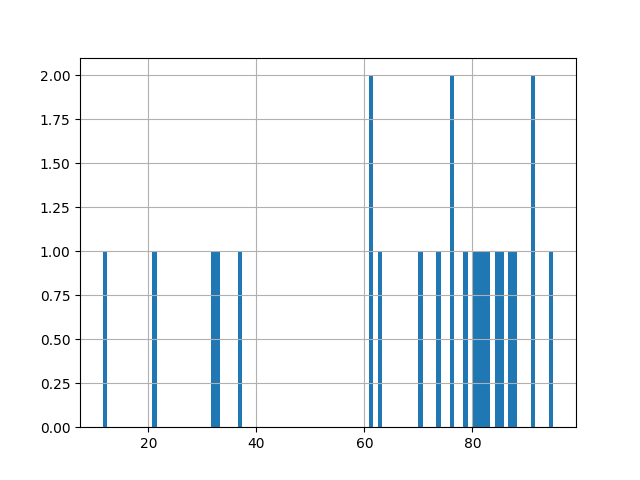

In [6]:
plt.subplots()
points = exam_results["Test Results in Points"]
points.hist(bins=100)

plt.show()

In [8]:
points = pd.DataFrame(points)
points.columns = ["points"]
points.head()

,points
student_id,
qy72fexa,87.0
bu41lobi,85.0
vy06qypi,81.0
ow85ymut,79.0
xy37jeqy,62.5


In [15]:
pass_score = 45.0
max_score = 100.0
bin_size = round((max_score-pass_score) / 11, 1)
bin_size

5.0

In [16]:
grades = [1.0, 1.33, 1.66, 2.0, 2.33, 2.66, 3.0, 3.33, 3.66, 4.0, 4.33, 5.0]
grades = grades[::-1]

In [17]:
min_points = [pass_score + bin_size * i for i in range(-2,len(grades)-1)]
min_points

[35.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0, 85.0, 90.0, 95.0]

In [18]:
grade_map = pd.DataFrame(zip(min_points, grades), columns=["min_points", "grade"])
grade_map["max_points"] = grade_map["min_points"] + bin_size - 0.1
grade_map.set_index("grade", inplace=True)
grade_map.loc[1.0, "max_points"] = max_score
grade_map.loc[5.0, "min_points"] = 0.0

grade_map.sort_index(inplace=True)

grade_map

,min_points,max_points
grade,,
1.00,90.0,100.0
1.33,85.0,89.9
1.66,80.0,84.9
2.00,75.0,79.9
2.33,70.0,74.9
2.66,65.0,69.9
3.00,60.0,64.9
3.33,55.0,59.9
3.66,50.0,54.9


In [19]:
# return the value of the index of grade_map where points is between min_points and max_points
points["grade"] = [grade_map[(grade_map["min_points"] <= point) & (grade_map["max_points"] >= point)].index[0] for point in points["points"]]
points


,points,grade
student_id,,
qy72fexa,87.0,1.33
bu41lobi,85.0,1.33
vy06qypi,81.0,1.66
ow85ymut,79.0,2.00
xy37jeqy,62.5,3.00
iz67evez,80.5,1.66
ug39owys,82.5,1.66
ot79cogo,11.5,5.00
id64ojik,32.5,5.00


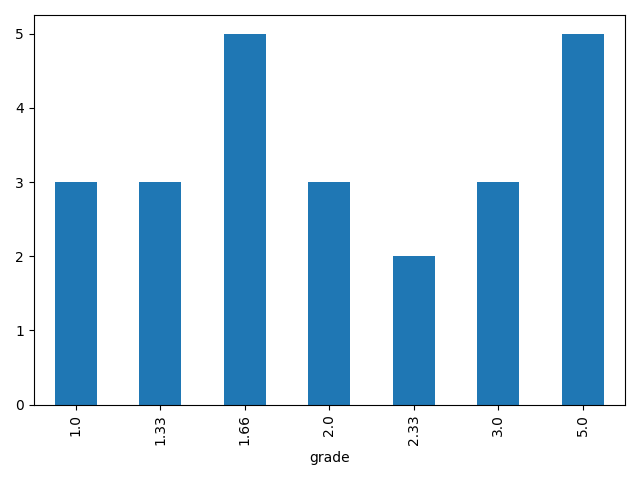

In [39]:
# Without Bonus

plt.subplots()

points["grade"].value_counts().sort_index().plot(kind="bar")

plt.tight_layout()

In [21]:
points.describe()

,points,grade
count,24.000000,24.000000
mean,68.458333,2.497917
std,23.927843,1.432426
min,11.500000,1.000000
25%,61.500000,1.577500
50%,77.750000,2.000000
75%,84.625000,3.000000
max,95.000000,5.000000


In [198]:
bonus_points = pd.read_csv("/Users/abelluc/Code/ads_exercise/total_score/2025_final.csv")
bonus_points.set_index("identifier", inplace=True)
bonus_points.index.names = ["student_id"]
bonus_points

,score_percent
student_id,
ab84abiq,54.000000
ac00ukok,100.000000
ac13atok,97.333333
ac41ycar,1.333333
ac83ekob,71.333333
...,...
yr06ixyv,12.000000
yr64yqys,93.333333
yv11ovir,77.333333


In [199]:
# join points and bonus_points

points = points.join(bonus_points)
# points.drop("student_id", axis=1, inplace=True)
points

,points,grade,score_percent
student_id,,,
mo76nery,76.5,1.66,95.333333
aq89opob,50.0,3.66,0.000000
pa57rapa,66.5,2.33,1.333333
no73widi,81.5,1.00,77.333333
pi44ditu,77.5,1.33,84.000000
...,...,...,...
if07iwul,68.0,2.33,84.666667
ed16eteh,73.5,1.66,NaN
li24qeku,73.0,1.66,100.000000


In [200]:
# replace values in score_percent with 0.33, 0.66, 1.0
points["bonus"] = np.zeros(len(points))

points["bonus"][points["score_percent"] >= 95] = 0.66
points["score_percent"][points["score_percent"] >= 95] = 0

points["bonus"][points["score_percent"] >= 90] = 0.33

# replace nan with 0
points.fillna(0, inplace=True)

points.drop("score_percent", axis=1, inplace=True)
points

/var/folders/3_/6bdchgy93zggkgq8kw8gyssr0000gn/T/ipykernel_88807/3821370881.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  points["bonus"][points["score_percent"] >= 95] = 0.66
/var/folders/3_/6bdchgy93zggkgq8kw8gyssr0000gn/T/ipykernel_

,points,grade,bonus
student_id,,,
mo76nery,76.5,1.66,0.66
aq89opob,50.0,3.66,0.00
pa57rapa,66.5,2.33,0.00
no73widi,81.5,1.00,0.00
pi44ditu,77.5,1.33,0.00
...,...,...,...
if07iwul,68.0,2.33,0.00
ed16eteh,73.5,1.66,0.00
li24qeku,73.0,1.66,0.66


In [201]:
points["grade_with_bonus"] = points["grade"] - points["bonus"]

# set grade_with_bonus to 1.0 if grade_with_bonus is smaller than 1.0
points["grade_with_bonus"][points["grade_with_bonus"] < 1.0] = 1.0

# set grade_with_bonus to grade value if grade is greater than 4.0
points["grade_with_bonus"][points["grade"] > 4.0] = points["grade"]

points

/var/folders/3_/6bdchgy93zggkgq8kw8gyssr0000gn/T/ipykernel_88807/3924598343.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  points["grade_with_bonus"][points["grade_with_bonus"] < 1.0] = 1.0
/var/folders/3_/6bdchgy93zggkgq8kw8gyssr0000gn

,points,grade,bonus,grade_with_bonus
student_id,,,,
mo76nery,76.5,1.66,0.66,1.00
aq89opob,50.0,3.66,0.00,3.66
pa57rapa,66.5,2.33,0.00,2.33
no73widi,81.5,1.00,0.00,1.00
pi44ditu,77.5,1.33,0.00,1.33
...,...,...,...,...
if07iwul,68.0,2.33,0.00,2.33
ed16eteh,73.5,1.66,0.00,1.66
li24qeku,73.0,1.66,0.66,1.00


In [202]:
points = round(points, 1)
points.sort_values("grade", inplace=True)
points

,points,grade,bonus,grade_with_bonus
student_id,,,,
im87ixel,81.0,1.0,0.7,1.0
og34yhyf,81.0,1.0,0.7,1.0
er73akad,85.0,1.0,0.7,1.0
aj41okaj,83.5,1.0,0.7,1.0
ka32qewe,83.0,1.0,0.0,1.0
...,...,...,...,...
yz32ityd,13.5,5.0,0.0,5.0
ib83icul,29.5,5.0,0.0,5.0
je42posy,38.5,5.0,0.0,5.0


In [203]:
points.describe()

,points,grade,bonus,grade_with_bonus
count,191.000000,191.000000,191.000000,191.000000
mean,69.018325,2.118848,0.243979,1.948691
std,12.785618,1.006171,0.328718,1.029760
min,13.500000,1.000000,0.000000,1.000000
25%,62.000000,1.300000,0.000000,1.000000
50%,73.000000,1.700000,0.000000,1.700000
75%,79.000000,2.700000,0.700000,2.300000
max,86.500000,5.000000,0.700000,5.000000


<Axes: xlabel='grade_with_bonus'>

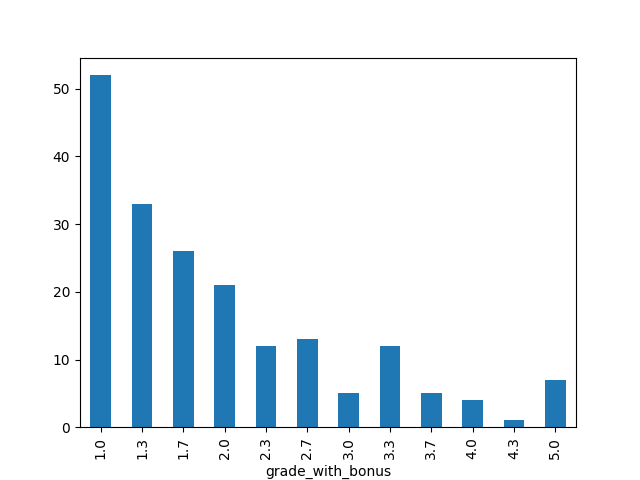

In [204]:
plt.subplots()
points["grade_with_bonus"].value_counts().sort_index().plot(kind="bar")

In [22]:
exam_result_path = Path("/Users/abelluc/FAUbox/DigiKolleg/ADS/Grading/2026-02_Retake/ADS_Retake_2026_results_final.csv")
points.to_csv(exam_result_path, sep=";")

### Write to campo excel sheet

In [30]:
# Load campo excel sheet
campo_path = Path("/Users/abelluc/FAUbox/DigiKolleg/ADS/Grading/2026-02_Retake/75441-Applied_Data_Science_in_Medicine_&_Psychology-WiSe_2025-1.xlsx")
campo = pd.read_excel(campo_path)
campo

/Users/abelluc/Code/ads_exercise/.venv/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,"75441 - Applied Data Science in Medicine & Psychology (Prüfung) | Prüfer/-in: Eskofier, Björn | Datum: 03.02.2026 | Wintersemester 2025/26 | Prüfungsperiode 1",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EXAM_CHECK_TOKEN,8322c22d987c405889ceffe88704d7e5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,startHISsheet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,endHISsheet
3,Examplan.id,Matrikelnummer,Bewertung,Nachname,Vorname,Benutzerkennung,Geschlecht,Versuch (V),Status,ECTS-Punkte,...,Jahr,Prüfungsperiode,Vermerk,Studiengang,Datum,Uhrzeit von,Uhrzeit bis,Prüfungsdatum (Leistung),Fachsemester (F),LockVersion
4,15938432,23224505,NaN,Ali,Shafaq,iz84elys,männlich,2,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,7.0,"b8fc4af8-21e1-4c28-94bb-fa89da9f79fe=0,200c1b1..."
5,15918634,23106205,NaN,Ananda Kumar,Tejashree,qy72fexa,weiblich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,7.0,"dfefa593-9913-4bb8-9eef-c637a2ce538a=0,98be403..."
6,15825857,23469960,NaN,Ande,Sandeep,bu41lobi,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,4.0,"47897257-d905-4f17-bed7-abde46f020a0=0,e7ea114..."
7,15812794,23082316,NaN,Chakraborty,Debanjan,vy06qypi,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,8.0,"2554bfa3-c5f4-4dd2-ad6b-0b4f430784b6=0,a23972d..."
8,15792864,23208381,NaN,Chattopadhyay,Souhardya,ow85ymut,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,7.0,"adb4e18f-4a65-4b3d-84e7-61b7f933ccb7=0,d33fbad..."
9,15910076,23466680,NaN,Chavan,Vaibhav Shashikant,xy37jeqy,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Autonomy Technologies (PO 20232),03.02.2026,10:00,11:00,03.02.2026,4.0,"262f96af-121a-45d8-86ad-afc252fe2539=0,e7432d7..."


In [31]:
# save campo column order
campo_column_order = campo.columns

In [32]:
campo.set_index("Unnamed: 5", inplace=True)

campo.index.names = ["student_id"]

campo["Unnamed: 2"] = points["grade"]

campo.reset_index(inplace=True)

# rename columns
campo.rename(columns={
    "student_id": "Unnamed: 5",}, inplace=True)

In [33]:
campo

,Unnamed: 5,"75441 - Applied Data Science in Medicine & Psychology (Prüfung) | Prüfer/-in: Eskofier, Björn | Datum: 03.02.2026 | Wintersemester 2025/26 | Prüfungsperiode 1",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,EXAM_CHECK_TOKEN,8322c22d987c405889ceffe88704d7e5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,startHISsheet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,endHISsheet
3,Benutzerkennung,Examplan.id,Matrikelnummer,NaN,Nachname,Vorname,Geschlecht,Versuch (V),Status,ECTS-Punkte,...,Jahr,Prüfungsperiode,Vermerk,Studiengang,Datum,Uhrzeit von,Uhrzeit bis,Prüfungsdatum (Leistung),Fachsemester (F),LockVersion
4,iz84elys,15938432,23224505,NaN,Ali,Shafaq,männlich,2,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,7.0,"b8fc4af8-21e1-4c28-94bb-fa89da9f79fe=0,200c1b1..."
5,qy72fexa,15918634,23106205,1.33,Ananda Kumar,Tejashree,weiblich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,7.0,"dfefa593-9913-4bb8-9eef-c637a2ce538a=0,98be403..."
6,bu41lobi,15825857,23469960,1.33,Ande,Sandeep,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,4.0,"47897257-d905-4f17-bed7-abde46f020a0=0,e7ea114..."
7,vy06qypi,15812794,23082316,1.66,Chakraborty,Debanjan,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,8.0,"2554bfa3-c5f4-4dd2-ad6b-0b4f430784b6=0,a23972d..."
8,ow85ymut,15792864,23208381,2.00,Chattopadhyay,Souhardya,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,7.0,"adb4e18f-4a65-4b3d-84e7-61b7f933ccb7=0,d33fbad..."
9,xy37jeqy,15910076,23466680,3.00,Chavan,Vaibhav Shashikant,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Autonomy Technologies (PO 20232),03.02.2026,10:00,11:00,03.02.2026,4.0,"262f96af-121a-45d8-86ad-afc252fe2539=0,e7432d7..."


In [34]:
# reorder campo columns to match original order
campo = campo[campo_column_order]

In [35]:
campo

,"75441 - Applied Data Science in Medicine & Psychology (Prüfung) | Prüfer/-in: Eskofier, Björn | Datum: 03.02.2026 | Wintersemester 2025/26 | Prüfungsperiode 1",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EXAM_CHECK_TOKEN,8322c22d987c405889ceffe88704d7e5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,startHISsheet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,endHISsheet
3,Examplan.id,Matrikelnummer,NaN,Nachname,Vorname,Benutzerkennung,Geschlecht,Versuch (V),Status,ECTS-Punkte,...,Jahr,Prüfungsperiode,Vermerk,Studiengang,Datum,Uhrzeit von,Uhrzeit bis,Prüfungsdatum (Leistung),Fachsemester (F),LockVersion
4,15938432,23224505,NaN,Ali,Shafaq,iz84elys,männlich,2,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,7.0,"b8fc4af8-21e1-4c28-94bb-fa89da9f79fe=0,200c1b1..."
5,15918634,23106205,1.33,Ananda Kumar,Tejashree,qy72fexa,weiblich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,7.0,"dfefa593-9913-4bb8-9eef-c637a2ce538a=0,98be403..."
6,15825857,23469960,1.33,Ande,Sandeep,bu41lobi,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,4.0,"47897257-d905-4f17-bed7-abde46f020a0=0,e7ea114..."
7,15812794,23082316,1.66,Chakraborty,Debanjan,vy06qypi,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,8.0,"2554bfa3-c5f4-4dd2-ad6b-0b4f430784b6=0,a23972d..."
8,15792864,23208381,2.00,Chattopadhyay,Souhardya,ow85ymut,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,7.0,"adb4e18f-4a65-4b3d-84e7-61b7f933ccb7=0,d33fbad..."
9,15910076,23466680,3.00,Chavan,Vaibhav Shashikant,xy37jeqy,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Autonomy Technologies (PO 20232),03.02.2026,10:00,11:00,03.02.2026,4.0,"262f96af-121a-45d8-86ad-afc252fe2539=0,e7432d7..."


In [36]:
# add back "Bewertung" to cell "Unnamed: 2", index 3
campo.at[3, "Unnamed: 2"] = "Bewertung"

/var/folders/3_/6bdchgy93zggkgq8kw8gyssr0000gn/T/ipykernel_34141/1480608873.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Bewertung' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  campo.at[3, "Unnamed: 2"] = "Bewertung"


In [37]:
campo

,"75441 - Applied Data Science in Medicine & Psychology (Prüfung) | Prüfer/-in: Eskofier, Björn | Datum: 03.02.2026 | Wintersemester 2025/26 | Prüfungsperiode 1",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EXAM_CHECK_TOKEN,8322c22d987c405889ceffe88704d7e5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,startHISsheet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,endHISsheet
3,Examplan.id,Matrikelnummer,Bewertung,Nachname,Vorname,Benutzerkennung,Geschlecht,Versuch (V),Status,ECTS-Punkte,...,Jahr,Prüfungsperiode,Vermerk,Studiengang,Datum,Uhrzeit von,Uhrzeit bis,Prüfungsdatum (Leistung),Fachsemester (F),LockVersion
4,15938432,23224505,NaN,Ali,Shafaq,iz84elys,männlich,2,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,7.0,"b8fc4af8-21e1-4c28-94bb-fa89da9f79fe=0,200c1b1..."
5,15918634,23106205,1.33,Ananda Kumar,Tejashree,qy72fexa,weiblich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,7.0,"dfefa593-9913-4bb8-9eef-c637a2ce538a=0,98be403..."
6,15825857,23469960,1.33,Ande,Sandeep,bu41lobi,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,4.0,"47897257-d905-4f17-bed7-abde46f020a0=0,e7ea114..."
7,15812794,23082316,1.66,Chakraborty,Debanjan,vy06qypi,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,8.0,"2554bfa3-c5f4-4dd2-ad6b-0b4f430784b6=0,a23972d..."
8,15792864,23208381,2.0,Chattopadhyay,Souhardya,ow85ymut,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Data Science (PO 20212),03.02.2026,10:00,11:00,03.02.2026,7.0,"adb4e18f-4a65-4b3d-84e7-61b7f933ccb7=0,d33fbad..."
9,15910076,23466680,3.0,Chavan,Vaibhav Shashikant,xy37jeqy,männlich,1,zugelassen,NaN,...,2025,1,NaN,M.Sc. Autonomy Technologies (PO 20232),03.02.2026,10:00,11:00,03.02.2026,4.0,"262f96af-121a-45d8-86ad-afc252fe2539=0,e7432d7..."


In [38]:

# export
campo.to_excel(campo_path.parent / "campo_test.xlsx", index=False, header=True, sheet_name="First Sheet")

/var/folders/3_/6bdchgy93zggkgq8kw8gyssr0000gn/T/ipykernel_34141/4267694228.py:2: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '1.4.5' currently installed).
  campo.to_excel(campo_path.parent / "campo_test.xlsx", index=False, header=True, sheet_name="First Sheet")
